In [10]:
import pandas as pd
# import pickle
import os
print('CWD is ',os.getcwd())

# Vis Libs..
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["axes.grid"] = False

CWD is  D:\ProyectoIA


In [5]:
def load_data():
    """
    Esta función lee datos de los respectivos directorios de entrenamiento.
    Esta función crea 1 dataframes con la información de los datos
    """

    train = pd.read_csv('train_sin_4.csv')
    
    train_dir = os.path.join('./','train_images/')
    
    train['file_path'] = train['id_code'].map(lambda x: os.path.join(train_dir,'{}.png'.format(x)))
    
    train['file_name'] = train["id_code"].apply(lambda x: x + ".png")
    
    train['diagnosis'] = train['diagnosis'].astype(str)
    
    return train

In [6]:
df_train = load_data()
print(df_train.shape,'\n')
df_train.head(6)

(3367, 4) 



,id_code,diagnosis,file_path,file_name
0,000c1434d8d7,2,./train_images/000c1434d8d7.png,000c1434d8d7.png
1,0024cdab0c1e,1,./train_images/0024cdab0c1e.png,0024cdab0c1e.png
2,002c21358ce6,0,./train_images/002c21358ce6.png,002c21358ce6.png
3,005b95c28852,0,./train_images/005b95c28852.png,005b95c28852.png
4,0097f532ac9f,0,./train_images/0097f532ac9f.png,0097f532ac9f.png
5,00a8624548a9,2,./train_images/00a8624548a9.png,00a8624548a9.png


In [12]:
df_train_3 = df_train[df_train["diagnosis"] == '3']
print(df_train_3.shape,'\n')
df_train_3.head(6)

(193, 4) 



,id_code,diagnosis,file_path,file_name
11,0104b032c141,3,./train_images/0104b032c141.png,0104b032c141.png
41,03c85870824c,3,./train_images/03c85870824c.png,03c85870824c.png
48,042470a92154,3,./train_images/042470a92154.png,042470a92154.png
66,05cd0178ccfe,3,./train_images/05cd0178ccfe.png,05cd0178ccfe.png
73,069f43616fab,3,./train_images/069f43616fab.png,069f43616fab.png
79,070f67572d03,3,./train_images/070f67572d03.png,070f67572d03.png


In [14]:
df_train = pd.concat([df_train, df_train_3], ignore_index=True)
print(df_train.shape,'\n')
df_train.head(6)

(3560, 4) 



,id_code,diagnosis,file_path,file_name
0,000c1434d8d7,2,./train_images/000c1434d8d7.png,000c1434d8d7.png
1,0024cdab0c1e,1,./train_images/0024cdab0c1e.png,0024cdab0c1e.png
2,002c21358ce6,0,./train_images/002c21358ce6.png,002c21358ce6.png
3,005b95c28852,0,./train_images/005b95c28852.png,005b95c28852.png
4,0097f532ac9f,0,./train_images/0097f532ac9f.png,0097f532ac9f.png
5,00a8624548a9,2,./train_images/00a8624548a9.png,00a8624548a9.png


### <font color='red'> 2.1 Distribucion de Clases </font>

In [8]:
'''This Function Plots a Bar plot of output Classes Distribution'''

def plot_classes(df):
    df_group = pd.DataFrame(df.groupby('diagnosis').agg('size').reset_index())
    df_group.columns = ['diagnosis','count']

    sns.set(rc={'figure.figsize':(10,5)}, style = 'whitegrid')
    sns.barplot(x = 'diagnosis',y='count',data = df_group,palette = "Blues_d")
    plt.title('Output Class Distribution')
    plt.show() 

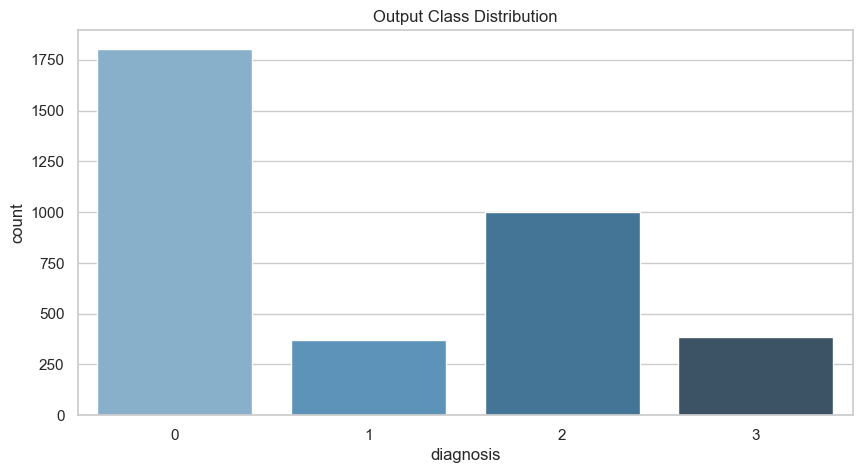

In [15]:
plot_classes(df_train)

In [16]:
df_train.to_csv("train_duplicado.csv", index=False)